#Introduction

This project aims to determine whether school performance, measured by average ACT scores, is predicted by socioeconomic factors. These factors include median income, employment rate, the percentage of students receiving free and reduced-price lunch, and student teacher ratios. This notebook, in particular, aims to explore the data and merge the three datasets to create one tidy dataset for analysis.

## Sources

https://www.edgap.org/#5/37.719/-96.899

https://data-nces.opendata.arcgis.com/datasets/43b42be85c4749e48267f83f1f6ffa60_0/explore?location=32.339121%2C-96.020508%2C4.46&showTable=true

https://www.dropbox.com/scl/fi/o8wf1f534pb4u7uavgjxm/ccd_sch_029_1617_w_1a_11212017.csv?rlkey=k2aey38xie2vz9ge4a0v3rrib&e=1&dl=0

# Load Data

Import Libraries

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

Load Edgap Data

In [2]:
edgap = pd.read_excel(
    'https://raw.githubusercontent.com/naomi-rlm/Education/main/data/EdGap_data.xlsx',
    dtype={'NCESSCH School ID': object}
)

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Load Common Core School Info

In [3]:
!wget -O ccd_sch_029_1617_w_1a_11212017.csv https://www.dropbox.com/s/lkl5nvcdmwyoban/ccd_sch_029_1617_w_1a_11212017.csv?dl=0

--2025-10-25 22:08:22--  https://www.dropbox.com/s/lkl5nvcdmwyoban/ccd_sch_029_1617_w_1a_11212017.csv?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/o8wf1f534pb4u7uavgjxm/ccd_sch_029_1617_w_1a_11212017.csv?rlkey=k2aey38xie2vz9ge4a0v3rrib&dl=0 [following]
--2025-10-25 22:08:23--  https://www.dropbox.com/scl/fi/o8wf1f534pb4u7uavgjxm/ccd_sch_029_1617_w_1a_11212017.csv?rlkey=k2aey38xie2vz9ge4a0v3rrib&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucad7785b9a752271f00aafc2740.dl.dropboxusercontent.com/cd/0/inline/Cz61I3K-tcGRPAoGhCsyMStBGtQsY_31Js-uslK1HbtLjWxYb8zAAA6EpMAMnP3Xz2JNTdo0a_1GU_HtS0SGI0eaoAwX4mCrVCKPjRd_a55C3B70GtFUCrQa43XosKbW5Fc/file# [following]
--2025-10-25 22:08:24--  https://ucad7

In [4]:
school_charateristics = pd.read_csv(
    'https://raw.githubusercontent.com/naomi-rlm/Education/main/data/School_District_Characteristics_2019-20.csv',
)

In [5]:
school_information = pd.read_csv(
    "ccd_sch_029_1617_w_1a_11212017.csv", encoding="unicode_escape"
)

/tmp/ipython-input-2591098979.py:1: DtypeWarning: Columns (6,9,14,15,18,19,21,22,25,26,29,31,35,39,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  school_information = pd.read_csv(


In [6]:
# This gives us info on what columns, NAs, number of enties and data types exist in this data set
school_charateristics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13117 entries, 0 to 13116
Data columns (total 31 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SURVYEAR        13117 non-null  object 
 1   STABR           13117 non-null  object 
 2   STATENAME       13117 non-null  object 
 3   LEAID           13117 non-null  int64  
 4   ST_LEAID        13117 non-null  object 
 5   LEA_NAME        13117 non-null  object 
 6   LSTREET1        13117 non-null  object 
 7   LSTREET2        193 non-null    object 
 8   LCITY           13117 non-null  object 
 9   LSTATE          13117 non-null  object 
 10  LZIP            13117 non-null  int64  
 11  LZIP4           13117 non-null  object 
 12  LEA_TYPE_TEXT   13117 non-null  object 
 13  LEA_TYPE        13117 non-null  int64  
 14  GSLO            13117 non-null  object 
 15  GSHI            13117 non-null  object 
 16  SY_STATUS_TEXT  13117 non-null  object 
 17  SCH             13117 non-null 

In [7]:
# This gives us info on what columns, NAs, number of enties and data types exist in this data set
edgap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NCESSCH School ID                                7986 non-null   object 
 1   CT Unemployment Rate                             7972 non-null   float64
 2   CT Pct Adults with College Degree                7973 non-null   float64
 3   CT Pct Childre In Married Couple Family          7961 non-null   float64
 4   CT Median Household Income                       7966 non-null   float64
 5   School ACT average (or equivalent if SAT score)  7986 non-null   float64
 6   School Pct Free and Reduced Lunch                7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


In [8]:
# This gives us info on what columns, NAs, number of enties and data types exist in this data set
school_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 65 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SCHOOL_YEAR          102183 non-null  object 
 1   FIPST                102183 non-null  int64  
 2   STATENAME            102183 non-null  object 
 3   ST                   102183 non-null  object 
 4   SCH_NAME             102183 non-null  object 
 5   LEA_NAME             102183 non-null  object 
 6   STATE_AGENCY_NO      102183 non-null  object 
 7   UNION                2533 non-null    float64
 8   ST_LEAID             102183 non-null  object 
 9   LEAID                102183 non-null  object 
 10  ST_SCHID             102183 non-null  object 
 11  NCESSCH              102181 non-null  float64
 12  SCHID                102181 non-null  float64
 13  MSTREET1             102181 non-null  object 
 14  MSTREET2             1825 non-null    object 
 15  MSTREET3         

# Looking at Relationships Between Variables and Checking Accuracy

All Relationships

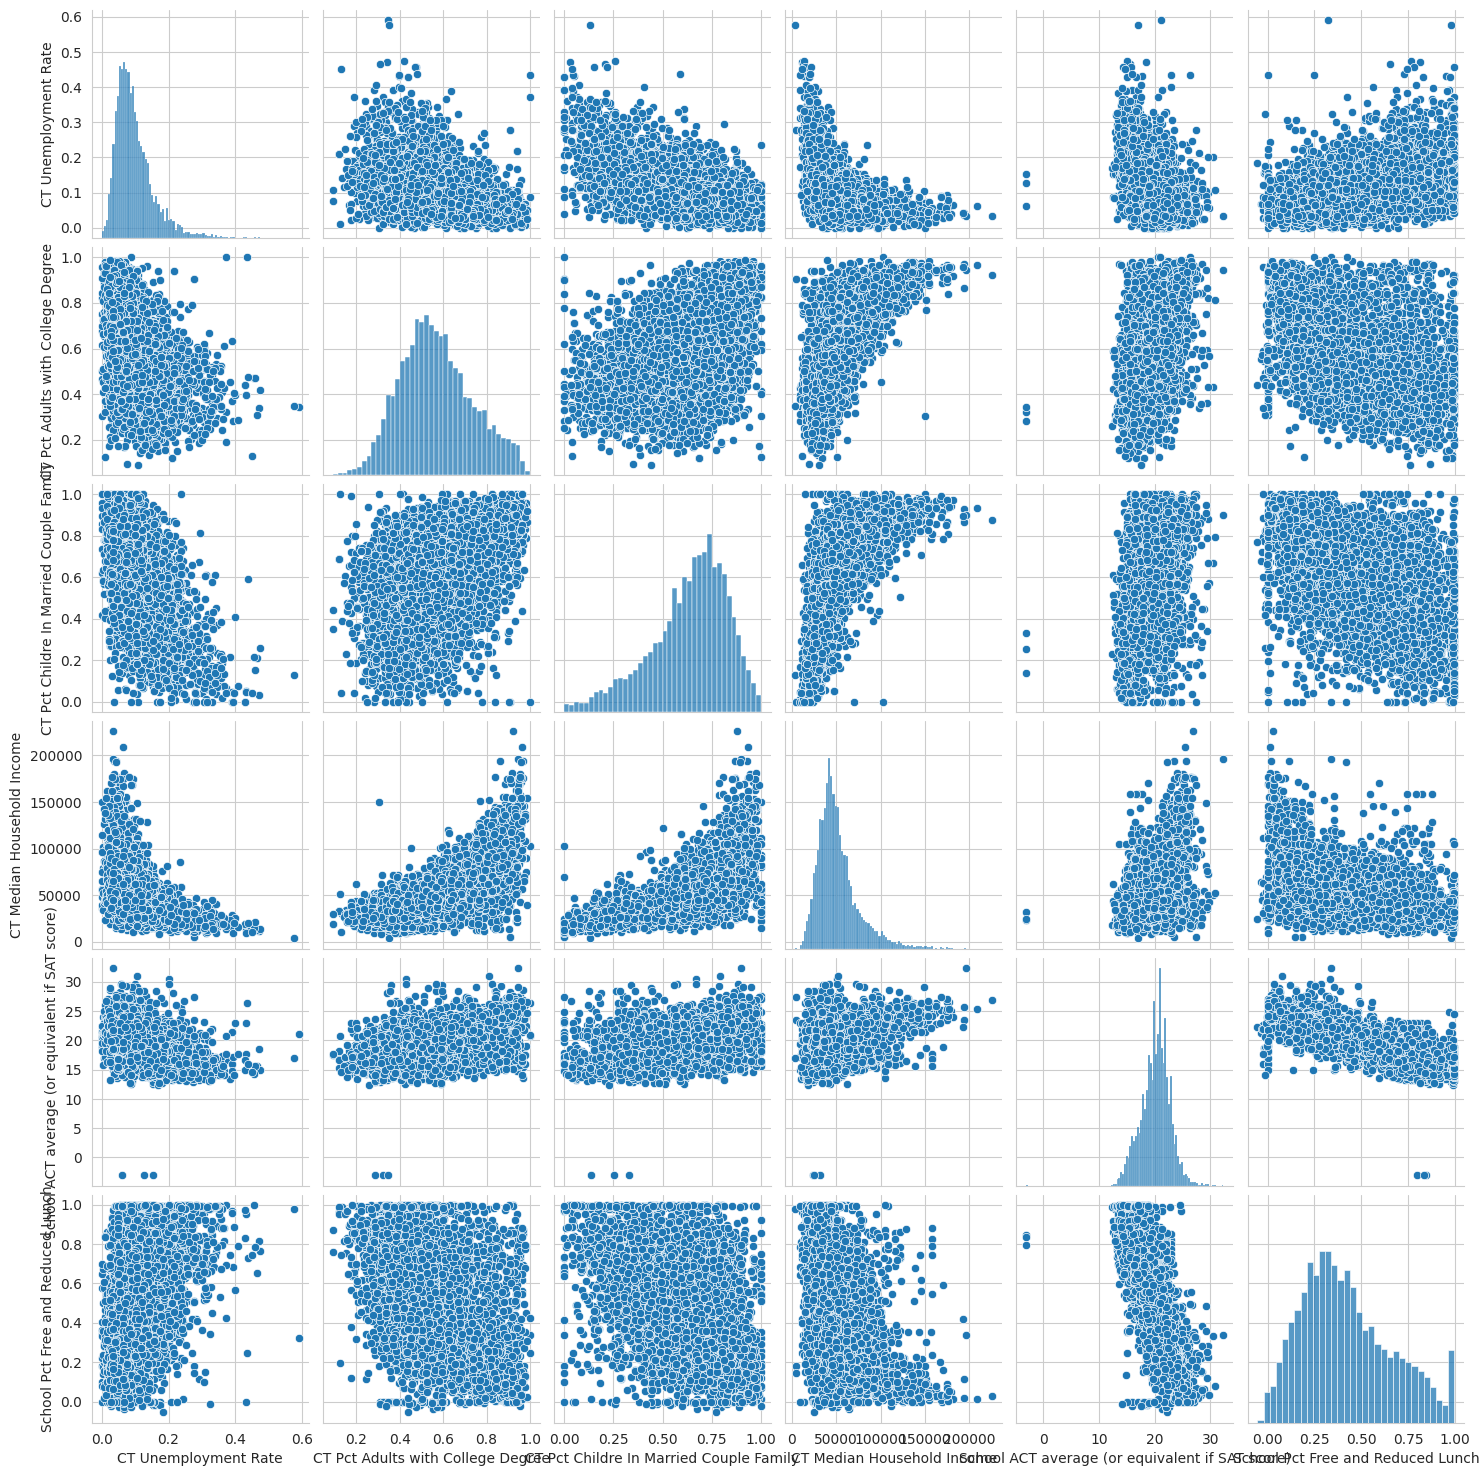

In [9]:
# Plots pairwise relationships for all numeric columns in `edgap` (excluding the ID column),
# showing histograms/KDEs on the diagonal and scatterplots off diagonal to visualize correlations.

sns.pairplot(
    edgap.drop(columns="NCESSCH School ID")
);
plt.show()

Add a Regression Line

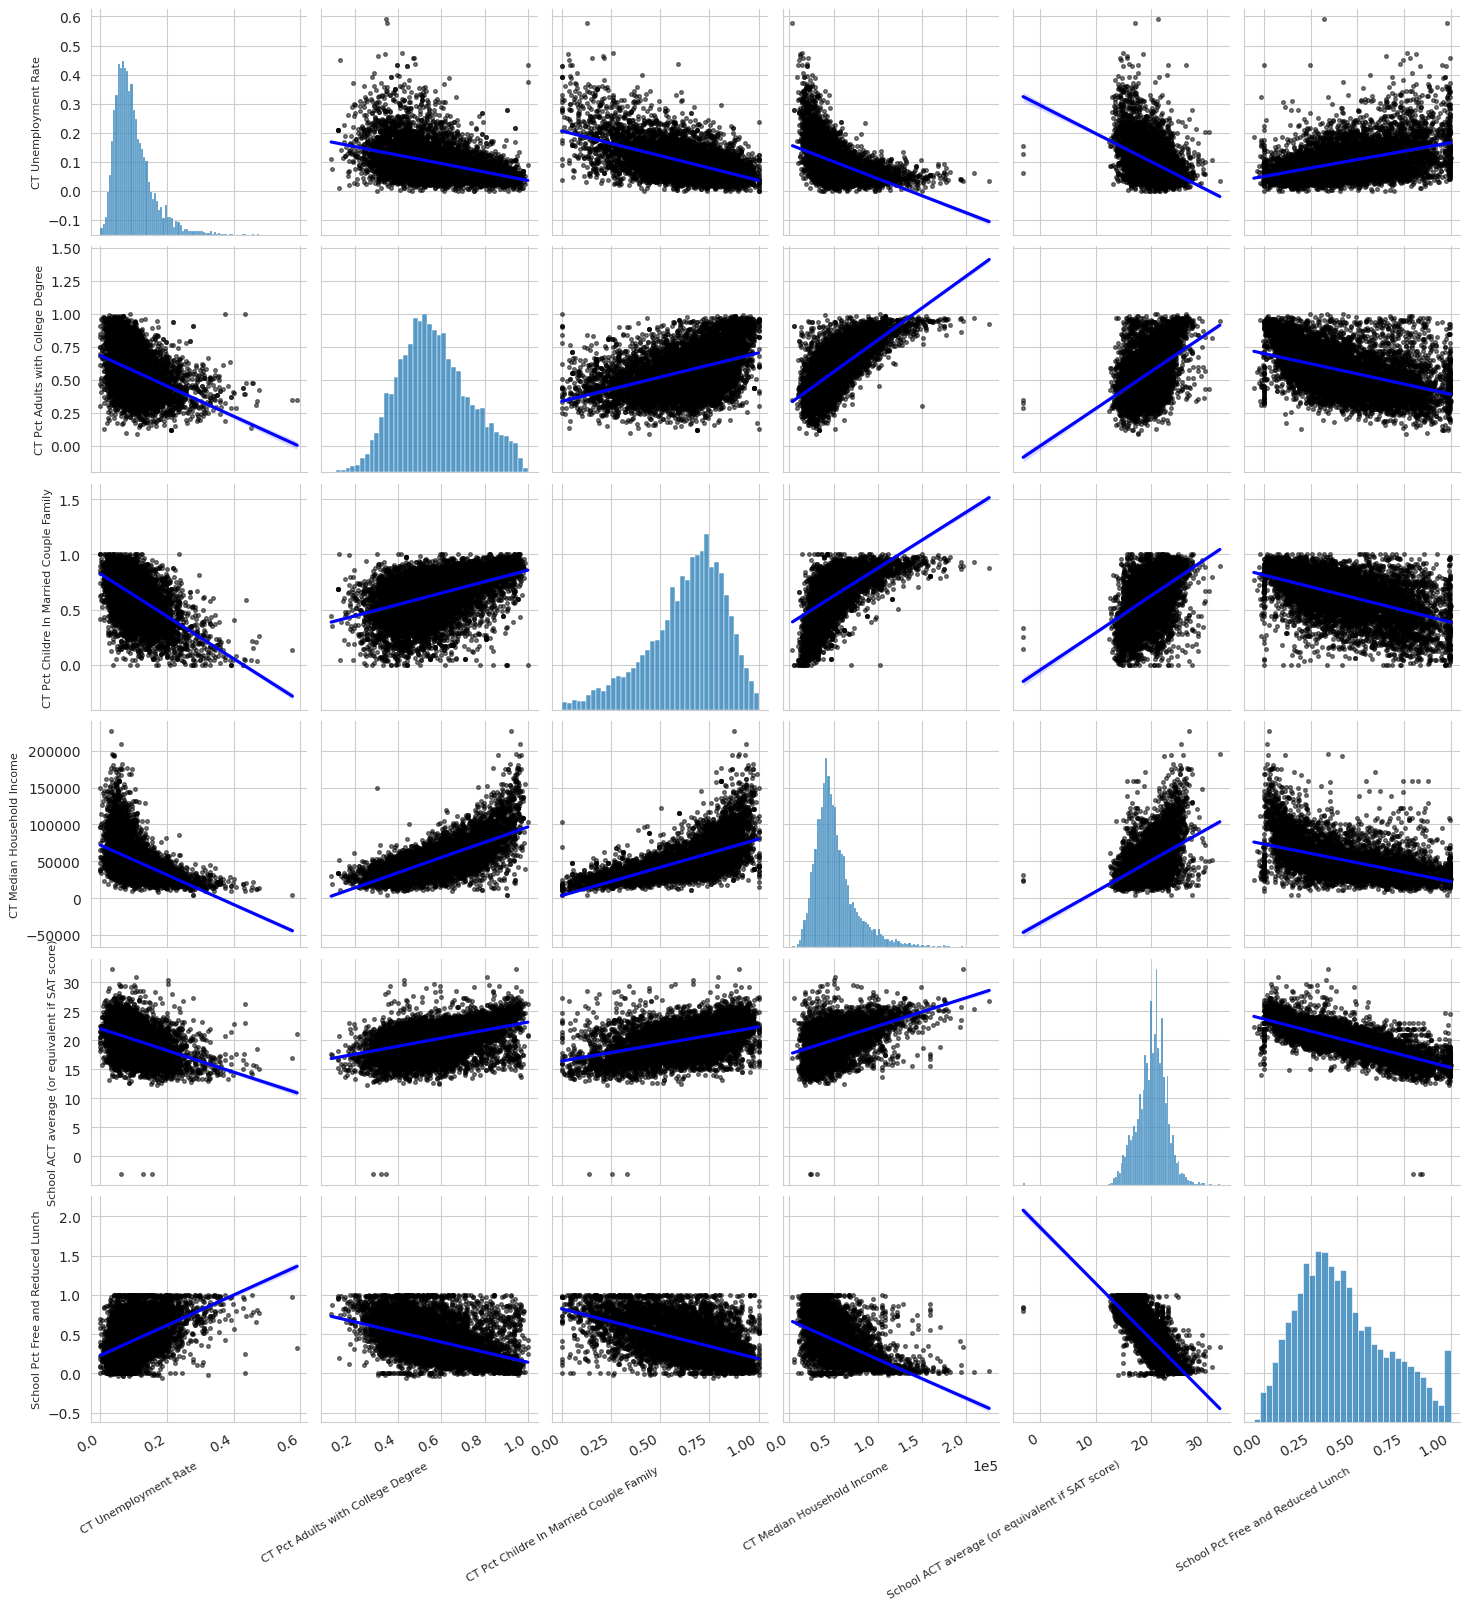

In [10]:
# Creates a Seaborn pairplot with regression lines for all numeric columns in `edgap`
# (dropping the ID column). Customizes line/scatter style, formats the x-axis for
# “CT Median Household Income” in scientific notation, and sets small, rotated axis/tick
# labels for readability before displaying the figure.

fig = sns.pairplot(
    edgap.drop(columns="NCESSCH School ID"),
    kind="reg",
    plot_kws={
        "line_kws": {"color": "blue"},
        "scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')


plt.show()

Only Looking at Act/Sat Score Relationships

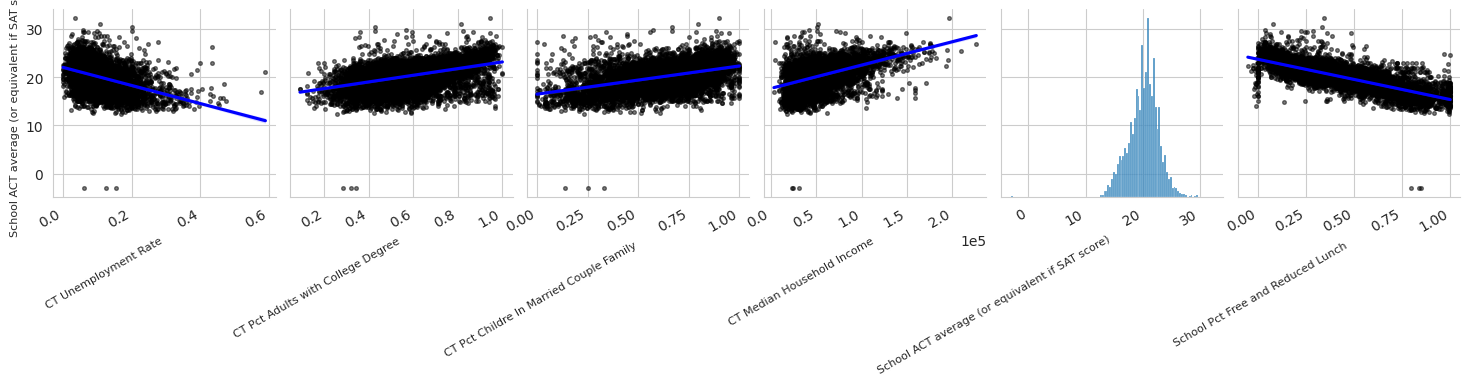

In [11]:
# Builds a Seaborn pairplot that regresses each predictor against the single
# response variable “School ACT average (or equivalent if SAT score)”.
# - Drops the ID column.
# - Uses kind='reg' to add best-fit lines and customizes line/scatter style.
# - For the “CT Median Household Income” axis, formats ticks in scientific notation.
# - Shrinks/rotates axis labels and x-ticks for readability.
# - Shows the resulting grid of scatterplots with regression lines and the
#   response variable’s histogram on the diagonal.

fig = sns.pairplot(
    edgap.drop(columns="NCESSCH School ID"),
    y_vars=['School ACT average (or equivalent if SAT score)'],
    kind="reg",
    plot_kws={
        "line_kws": {"color": "blue"},
        "scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

# Data Preparation

Narrowing the Data Set to Whats Useful

In [12]:
# Keep only the columns needed for merging/analysis from `school_information`.
# Year, school ID, location fields, and high-level school descriptors.

school_information = school_information[
    ['SCHOOL_YEAR', 'NCESSCH', 'LSTATE', 'LZIP', 'SCH_TYPE_TEXT', 'LEVEL', 'CHARTER_TEXT']
]

In [13]:
# Keep only the columns needed from `school_characteristics`.
# Location keys plus enrollment, staffing, student–teacher ratio, and grade bounds.

school_charateristics = school_charateristics[
    ['LSTATE', 'LZIP', 'MEMBER', 'TOTTCH', 'STUTERATIO', "GSLO", "GSHI"]
]

In [14]:
# Standardize `edgap` column names to readable, snake-case variables
# that match your analysis vocabulary for easier comprehension and future merges

edgap = edgap.rename(
    columns={
        "NCESSCH School ID": "id",
        "CT Pct Adults with College Degree": "percent_college",
        "CT Unemployment Rate": "rate_unemployment",
        "CT Pct Childre In Married Couple Family": "percent_married",
        "CT Median Household Income": "median_income",
        "School ACT average (or equivalent if SAT score)": "average_act",
        "School Pct Free and Reduced Lunch": "percent_lunch",
    }
)

In [15]:
# Rename `school_information` columns to consistent keys for merging and analysis

school_information = school_information.rename(
    columns={
        "SCHOOL_YEAR": "year",
        "NCESSCH": "id",
        "LSTATE": "state",
        "LZIP": "zip_code",
        "SCH_TYPE_TEXT": "school_type",
        "LEVEL": "school_level",
        "CHARTER_TEXT": "charter"
    }
)

In [16]:
# Rename `school_characteristics` columns to standardized names

school_charateristics = school_charateristics.rename(
    columns={
        "LSTATE": "state",
        "LZIP": "zip_code",
        "MEMBER": "total_students",
        "TOTTCH": "total_teachers",
        "STUTERATIO": "student_teacher_ratio",
        "GSLO": "lowest_grade",
        "GSHI": "highest_grade",
    }
)

In [17]:
# Ensure the join key has a consistent dtype before merging

school_information['id'] = school_information['id'].astype('object')

In [18]:
# First Left Join: attach school-level info to `edgap` by NCESSCH `id`.
# Keeps all rows from `edgap` and adds matching columns from `school_information`.

df_1 = edgap.merge(
    school_information,
    how='left',
    on='id'
)


In [19]:
# Left Join Two: enrich with school characteristics using location keys.
# Joins on ZIP code and state and preserves all rows from the previous merge.

df = df_1.merge(
    school_charateristics,
    how='left',
    on=['zip_code', 'state']
)

In [20]:
# Check new data set and verify it lookd as expected

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8971 entries, 0 to 8970
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     8971 non-null   object 
 1   rate_unemployment      8957 non-null   float64
 2   percent_college        8958 non-null   float64
 3   percent_married        8944 non-null   float64
 4   median_income          8951 non-null   float64
 5   average_act            8971 non-null   float64
 6   percent_lunch          8971 non-null   float64
 7   year                   8883 non-null   object 
 8   state                  8883 non-null   object 
 9   zip_code               8883 non-null   object 
 10  school_type            8883 non-null   object 
 11  school_level           8883 non-null   object 
 12  charter                8883 non-null   object 
 13  total_students         5535 non-null   float64
 14  total_teachers         5535 non-null   float64
 15  stud

In [21]:
# Check for outliers and data that doesn't make sense
df.select_dtypes(include=['number']).agg(['min', 'max']).round(2)

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,total_students,total_teachers,student_teacher_ratio
min,0.00,0.09,0.0,3589.0,-3.07,-0.05,8.0,0.00,-2.0
max,0.59,1.00,1.0,226181.0,32.36,1.00,347484.0,21943.44,31.3


In [22]:
# Replace non-positive student–teacher ratios with NaN
# 0 or less ratio means there must be an issue with the data as it isn't possible

df.loc[df['student_teacher_ratio'] <= 0, 'student_teacher_ratio'] = np.nan

In [23]:
# Replace non-positive teacher values with NaN
# Can't have 0 or less teachers

df.loc[df['total_teachers']  <= 0, 'total_teachers']  = np.nan

In [24]:
# Replace any negative free/reduced-price lunch percentages with NaN

df.loc[df['percent_lunch'] < 0, 'percent_lunch'] = np.nan

In [25]:
# Replace implausibly low ACT averages with NaN

df.loc[df['average_act'] < 1, 'average_act'] = np.nan

In [26]:
# Keep only high schools for the analysis

df = df.loc[df['school_level'] == 'High']

In [27]:
# Check number of missing values for each variable

df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
percent_married,22
median_income,16
average_act,3
percent_lunch,27
year,0
state,0
zip_code,0


In [28]:
# Import libraries to plot a choropleth map
import plotly.offline as po
import plotly.graph_objs as pg

In [29]:
# Plot a choropleth map of U.S. states showing how many schools are in each state

layout = dict(
    geo={"scope": "usa"}, coloraxis_colorbar=dict(title="Number of Schools")
)

data = dict(
    type="choropleth",
    locations=df["state"].value_counts().index,
    locationmode="USA-states",
    z=df["state"].value_counts().values,
    coloraxis="coloraxis",
)

x = pg.Figure(data=[data], layout=layout)

po.iplot(x)

In [30]:
# Compute and map the share of missing data by state for columns relating to student teacher ratios data set

cols = ["total_students","total_teachers","student_teacher_ratio","lowest_grade","highest_grade"]
miss_prop = df.groupby("state")[cols].apply(lambda m: m.isna().mean()).mean(axis=1).sort_index()

layout = dict(
    geo={"scope": "usa"},
    coloraxis_colorbar=dict(title="Avg. % Missing\n(total_students → highest_grade)")
)

data = dict(
    type="choropleth",
    locations=miss_prop.index,
    locationmode="USA-states",
    z=(miss_prop.values * 100),
    coloraxis="coloraxis"
)

fig = pg.Figure(data=[data], layout=layout)
fig.show()

In [31]:
# Remove rows with missing target values so models/plots use complete ACT outcomes

df = df.dropna(subset=['average_act'])

In [32]:
# Define the predictor set for modeling

predictor_variables = [
    'rate_unemployment',
    'percent_college',
    'percent_married',
    'median_income',
    'percent_lunch',
    'state',
    'charter'
]

In [33]:
# Import scikit-learn’s multivariate imputer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [34]:
# Initialize the imputer

imputer = IterativeImputer()

In [35]:
# Select only numeric predictors from the predictor list

numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

print(numerical_predictors)

['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch']


In [36]:
# Fit the imputer on the numeric columns

imputer.fit(df.loc[:, numerical_predictors])

IterativeImputer()

In [37]:
# Transform the data, fill missing numeric values using the learned iterative model

df.loc[:, numerical_predictors] = imputer.transform(df.loc[:, numerical_predictors])

In [38]:
# Turn the cleaned dataset to CSV

df.to_csv(
    'education_clean.csv',
    encoding='utf-8-sig',
    index=False
)

In [39]:
# Download cleaned dataset

from google.colab import files

files.download('education_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>